# Volt-VAr-Induced Curtailment Detection

Find instances where active-power curtailment is happening *because* the inverter is absorbing
reactive power (Volt-VAr response) and has run out of apparent-power headroom.

## The physics logic

An inverter rated `S_rated` kVA can deliver any combination of active power `P` and reactive
power `Q` as long as they stay inside the **apparent-power circle**: `sqrt(P² + Q²) ≤ S_rated`.

When grid voltage is high (e.g. 240 to 258 V), AS/NZS 4777.2 requires the inverter to **absorb**
reactive power. That absorption consumes part of the apparent-power "budget", so
if the irradiance is strong enough that the inverter *wants* to push out a lot of `P`, it may be
**forced to reduce `P`** to make room for the required `Q`. That reduction is labelled **Volt-VAr-induced curtailment**, distinct from Volt-Watt curtailment (which only kicks in above 253 V).

## Conditions to find Volt-VAr-induced curtailment timestamps

| # | Condition | Reason |
|---|-----------|-----|
| 1 | Clear-sky day (GHI) | so we know the inverter *could* have produced near its max |
| 2 | Peak solar window (≈11:00 to 13:00)* | when `P` is naturally highest. Most likely to hit the limit (*might be irrelevant) |
| 3 | `240 < V < 253` | V-VAr absorbing is **active** (Australia A), but V-Watt is **not yet**. Isolates the Volt-VAr effect |
| → | `sqrt(P² + Q²) ≳ S_rated` | inverter is riding its apparent-power limit |

## Two complementary tests

| Method | Uses | Answers |
|--------|------|---------|
| **A: Symptom detection** | measured P, Q, V from `ts` | *Which sites/intervals show the inverter riding its apparent-power limit while absorbing VAr?* |
| **B: Counterfactual quantification** | `all_uncurtailedpv` (GHI model) | *How many kWh of P were actually lost to VAr?* |


###  Some notes
1. **Use `S_99`, not nameplate, for the limit**: the CICCADA data pipeline normalises by `S_99`
   (99th-percentile observed apparent power), because the *effective* inverter limit in the data
   is often below the nameplate. Using nameplate could under-count curtailment.(nameplate is also pulled)
2. **Reactive sign convention.** Everything here assumes **−Q = absorbing**. If the fleet's raw
   `energy_reactive` sign is flipped, the whole detection inverts. There's a sanity-check cell.
3. **"Clear sky" needs a definition.** GHI being *high* isn't enough. It must be *stable*
   (not punching through cloud gaps). We use `GHI / GHI_clear_sky` near 1.0 **and** low local
   variance. The `structured_data` table already has `ghi` and `ghi_cs` so we use their ratio.
4. **Peak-solar window is in local time.** `t_stamp` is UTC. Convert to AEST (UTC+10) first,
   or the 11:00 to 13:00 window lands in the wrong place.
5. **Three-phase sites.** Aggregate P and Q across **all** PV circuits before computing S, and use
   `max(voltage)` across circuits (the worst phase is what triggers the VAr response).

## Before running

### 1.  `ghi` and `ghi_cs` and how they are calculated?

Both live in **`structured_data`**, the table the GHI/curtailment pipeline is built from
(`ghi_pv_estimator_general/Write_structured_data.ipynb`). Neither is a raw satellite produc. Both are derived:

- **`ghi`**: Bureau of Meteorology / NCI satellite irradiance, natively **10-minute** resolution,
  matched to each site's nearest lat/long grid cell. It is resampled to 5-minute by **duplicating**
  each 10-min reading and shifting the copy +5 minutes (not interpolated). So odd 5-minute
  intervals carry the *same* GHI value as the preceding even one. This means the practical
  temporal resolution of `ghi` is still 10 minutes, not 5.

- **`ghi_cs`** ("clear-sky GHI"): *not* a physical clear-sky model (e.g. Ineichen). It's
  **empirical**: for each site, the pipeline finds the **clearest day per month** at that
  location (lowest summed cloud-type index, `cloud_sum < 60`, peak GHI `> 200`), then for any
  given day it finds the **nearest such clear-sky day** (by calendar distance, ≤45 days). Within
  that reference day, `ghi_cs` at each 5-minute time-of-day bin is the **60th percentile of GHI**
  over a ±3-interval rolling window (`approx_percentile(GHI, 0.6) OVER (... ROWS BETWEEN 3
  PRECEDING AND 3 FOLLOWING)`), computed within continuous data segments (a gap >30 min starts a
  new segment). 
  The same logic builds `P_kw_norm_cs`, the matching clear-sky **power** shape.

So `ghi/ghi_cs` is "how much sun today, relative to the clearest day this site saw nearby in the
calendar". Not an absolute clear-sky physics model. 

This matters for you: a "clear-sky" flag near `ghi/ghi_cs ≈ 1` only means *as clear as the best recent reference day*, which might be an imperfect proxy in persistently overcast regions.


### 2. On three phase inverters

For three-phase sites, the inverter typically
responds to **per-phase** voltage, but our 240–253 V eligibility test uses `max(V)` — the worst
phase. A three-phase site could have one phase at 248 V (V-VAr-eligible) while the other two sit
at 235 V (not eligible), yet our aggregate `P` and `Q` are summed across all three. This is a
known simplification (shared with the rest of the pipeline) — it slightly overstates eligibility
for three-phase sites. If you want a cleaner read on this specific question, set
`PHASE_FILTER = "single"` to restrict to single-phase sites only, where this ambiguity doesn't
arise.

## Setup

In [7]:
import sys
from pathlib import Path

# Search the current directory and its parents for the repository root.
_current = Path.cwd().resolve()

REPO_ROOT = next(
    (
        path
        for path in (_current, *_current.parents)
        if (path / "bms_sa_review").is_dir()
    ),
    None,
)

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not locate the repository root containing 'bms_sa_review'. "
        f"Current working directory: {_current}"
    )

if str(REPO_ROOT / "bms_sa_review") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "bms_sa_review"))

if str(REPO_ROOT / "bms_sa_review" / "data_query" / "lib") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "bms_sa_review" / "data_query" / "lib"))

    

print("Repository root:", REPO_ROOT)
print("Package exists:", (REPO_ROOT / "bms_sa_review").is_dir())

from bms_sa_review.shared.aws_config import aq, tables, databases

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
import pytz

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", font_scale=0.95)

Repository root: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA
Package exists: True


In [8]:
from bms_sa_review.data_query.lib.analysis_contract import AnalysisConfig, manifest
from bms_sa_review.shared.ciccada_config import AS4777

import bms_sa_review.data_query.lib.voltvar_queries as vq
import bms_sa_review.data_query.lib.voltvar_metrics as vm
import bms_sa_review.data_query.lib.voltvar_plots   as vpl

from bms_sa_review.data_query.lib.voltvar_params import PARAMS, describe

In [9]:
# Analysis configuration
# AnalysisConfig carries database, table names, and shared settings.
# VoltVarParams carries the Volt-VAr-specific detection window and filters.
# Both are frozen dataclasses; override with .with_changes() or replace().

config = AnalysisConfig()
params = PARAMS

print("Analysis configuration:")
display(manifest(config))
print()
print("Volt-VAr detection parameters:")
display(describe(params))

Analysis configuration:


,setting,value
0,database,solar_analytics_iceberg
1,years,"2024, 2025"
2,interval_minutes,5.0
3,site_nonconf_threshold,0.1
4,minimum_site_intervals,1
5,flex_selection,exclude
6,rating_basis,ac_capacity_kw
7,empirical_limit_basis,s_99
8,voltage_aggregation,avg
9,capability_profile,review_corrected



Volt-VAr detection parameters:


,parameter,value
0,years,"(2024, 2025)"
1,v_low,240.0
2,v_high,253.0
3,peak_hour_start,11
4,peak_hour_end,14
5,ghi_cs_ratio_min,0.95
6,apply_ghi_filter,True
7,empirical_limit_basis,s_99
8,tolerance_basis,ac_capacity_kw
9,tolerance_fraction,0.04


## 1. Input coverage

Quick check: do `structured_data` and `all_uncurtailedpv` have rows for the
requested years? If a year is absent here, the corresponding Method A/B output
will be empty.

In [10]:
coverage = vq.fetch_input_coverage(aq, config, params)
display(coverage)

,dataset,year,n_rows,n_sites
0,all_uncurtailedpv,2024,264337213,13844
1,all_uncurtailedpv,2025,222885527,12617
2,structured_data,2024,454425592,13967
3,structured_data,2025,387065417,12737


## 2. Method A: Fleet-wide symptom scan

This is the **screening** query. For each site-year it counts intervals that
simultaneously satisfy all of:

> GHI clear-sky filter (if enabled) **AND** peak solar window **AND**
> voltage in the Volt-VAr-only band **AND** absorbing Q **AND** operating at
> the apparent-power limit (within the tolerance band).

The result is a per-site-year table with `symptom_count` (how many intervals
show the symptom) and `headroom_displacement_kw_sum` (a first-order proxy for
lost active power, computed as the apparent-power headroom consumed by Q).

`method_a_summary` enriches this with `headroom_displacement_kwh` and flags
`affected` sites (those with ≥1 symptom interval).

In [11]:
method_a_raw = vq.fetch_method_a_site_year(aq, config, params)
method_a_enriched, method_a_yearly = vm.method_a_summary(
    method_a_raw, config.interval_h,
)

print(f"Method A: {method_a_enriched.site_id.nunique():,} eligible sites, "
      f"{int(method_a_enriched.symptom_count.sum()):,} symptom intervals")
display(method_a_yearly)
method_a_enriched.sort_values("symptom_count", ascending=False).head(20)

Method A: 14,557 eligible sites, 5,525,295 symptom intervals


,year,eligible_sites,symptom_sites,eligible_intervals,symptom_intervals,symptom_site_pct,symptom_interval_pct,headroom_displacement_proxy_kwh
0,2024,13080,6337,33605200,2909431,48.448012,8.657681,43606.020285
1,2025,11863,5774,28861208,2615864,48.672343,9.063598,38629.552410


,site_id,year,eligible_count,absorbing_q_count,symptom_count,headroom_displacement_kw_sum,avg_symptom_voltage,avg_symptom_p_kw,avg_symptom_q_kvar,headroom_displacement_kwh,affected
6461,276149647,2025,5799,5799,5018,1070.054832,246.743414,7.657310,-1.784229,89.171236,True
1770,276149647,2024,5563,5563,4748,928.853169,246.445925,7.670506,-1.711810,77.404431,True
5011,1859863480,2024,5534,5534,4455,1109.223587,247.612222,4.610187,-1.513084,92.435299,True
4890,35479265,2024,6270,6028,4432,144.575182,243.997856,4.844155,-0.522901,12.047932,True
4244,1752460611,2025,5801,5767,4413,130.918581,243.535305,4.904568,-0.500406,10.909882,True
7297,262504310,2025,5535,5535,4252,579.958127,245.805426,5.827062,-1.198128,48.329844,True
1610,362549697,2025,5240,5061,4243,2253.687943,248.163109,7.468264,-2.863509,187.807329,True
13014,749828049,2025,6104,6104,4146,1493.789608,248.205174,5.658030,-2.046522,124.482467,True
14184,199917962,2024,4835,4835,4125,1212.579216,247.150339,4.616671,-1.672706,101.048268,True
913,1178534656,2025,6118,6036,4105,473.756223,244.596188,4.832813,-1.018777,39.479685,True


### Columns breakdown

- **`symptom_count`**: 5-minute intervals this site-year spent in the detection
  window while riding the apparent-power limit (within the 4% tolerance). Higher
  = more affected.
- **`headroom_displacement_kwh`**: first-order proxy for energy lost — the
  apparent-power headroom consumed by Q, summed over symptom intervals and
  converted to kWh. This is an upper bound (assumes the inverter would have used
  all that headroom for P). Method B refines this with the counterfactual.
- **`eligible_count`**: total intervals in the detection window for this
  site-year, regardless of whether the symptom was present.
- **`avg_symptom_voltage`**, **`avg_symptom_p_kw`**, **`avg_symptom_q_kvar`**:
  average operating point during symptom intervals.

Sites at the top of this list are candidates for closer inspection in Method B.

## 3. Method B: Counterfactual attribution

Method A estimates lost energy from apparent-power headroom alone. Method B
uses the **counterfactual** (the GHI-based uncurtailed-P prediction from
`all_uncurtailedpv`) to quantify the actual displacement:

```
P_max_given_Q = sqrt(S_limit² − Q_measured²)
attributed_kW = max(0, P_counterfactual − max(P_measured, P_max_given_Q))
```

The attribution flows through four **evidence tiers**, each strictly nested
inside the previous one:

| Tier | Condition | Meaning |
|------|-----------|---------|
| 1 | Q < 0 | Inverter is absorbing reactive power |
| 2 | + at apparent-power limit | S ≈ S_limit (within tolerance) |
| 3 | + counterfactual > measured-Q headroom | The inverter *would* have produced more P absent the Q |
| 4 | + symptom present (if `require_apparent_limit_symptom`) | Attributable displacement with the strongest evidence |

**Tier 4** is the headline: intervals with both the symptom and a positive
counterfactual displacement.

### How `all_uncurtailedpv` is calculated

This is the counterfactual engine behind the whole notebook.
It's a five-stage pipeline (from the `ghi_pv_estimator_general` folder):

1. **`Write_structured_data`** builds the per-site, per-5-min feature table:
   actual power (normalised by `S_99`, not nameplate), matched `ghi`/`ghi_cs`,
   and the clear-sky power shape `P_kw_norm_cs`.
2. **`split_days`** randomly splits each site's distinct days 80/20 into
   train/validation (day-level).
3. **`model_ghi_norm`** fits, **per site and per 5-minute time-of-day bin**,
   the regression: `P_norm/P_norm_cs = a + b × (ghi/ghi_cs)`. The intercept is
   **pinned**: `a = 1 − b`, so that on a clear-sky day (`ghi/ghi_cs = 1`) the
   model reproduces the clear-sky reference shape exactly. Training only uses
   clean, uncurtailed observations: `V ≤ 253` (no V-Watt) and `P_norm ≥ 1 OR
   S_norm < 1.001` (no V-VAr curtailment already happening).
4. **`Write_All_uncartailedPV`** applies the model fleet-wide to predict
   `P_kw_norm_est`, then **floors the prediction at the actual measured value**
   (`uncurtailed_P = max(model_prediction, actual) × S_99`); curtailment can
   only ever *reduce* output, so the counterfactual is never allowed below what
   was actually measured.
5. A **MAPE < 50% quality gate** restricts the final table to sites where the
   model's accuracy is acceptable.

**Caveat**: because normalisation uses `S_99` rather than nameplate, sites that
have been persistently curtailed historically have a *depressed* `S_99`, which
understates their true uncurtailed potential.

In [12]:
method_b_raw = vq.fetch_method_b_site_year(aq, config, params)
method_b_enriched, method_b_yearly = vm.method_b_summary(
    method_b_raw, config.interval_h,
)

print(f"Method B: {method_b_enriched.site_id.nunique():,} eligible sites, "
      f"{int(method_b_enriched.tier4_attributed_count.sum()):,} Tier 4 intervals, "
      f"{method_b_enriched.attributed_measured_q_kwh.sum():,.1f} kWh attributed")
display(method_b_yearly)

Method B: 14,557 eligible sites, 672,953 Tier 4 intervals, 6,369.6 kWh attributed


,year,eligible_sites,counterfactual_covered_sites,tier1_absorbing_intervals,tier2_apparent_limit_intervals,tier3_counterfactual_above_headroom_intervals,tier4_attributed_intervals,tier4_affected_sites,attributed_measured_q_kwh,required_q_scenario_kwh,counterfactual_covered_potential_kwh,attributed_pct_of_covered_potential
0,2024,13080,12949,15280539,2909431,474323,373682,3124,3655.491763,15851.429268,1.098402e+07,0.033280
1,2025,11863,11724,13455736,2615864,374549,299271,2866,2714.091200,12259.603372,9.612079e+06,0.028236


### Evidence tier funnel

,evidence_tier,n_intervals,n_sites
0,Tier 1: absorbing Q,28736275,9793
1,Tier 2: apparent-limit symptom,5525295,7253
2,Tier 3: counterfactual above measured-Q headroom,848872,4618
3,Tier 4: symptom + attributable displacement,672953,3790


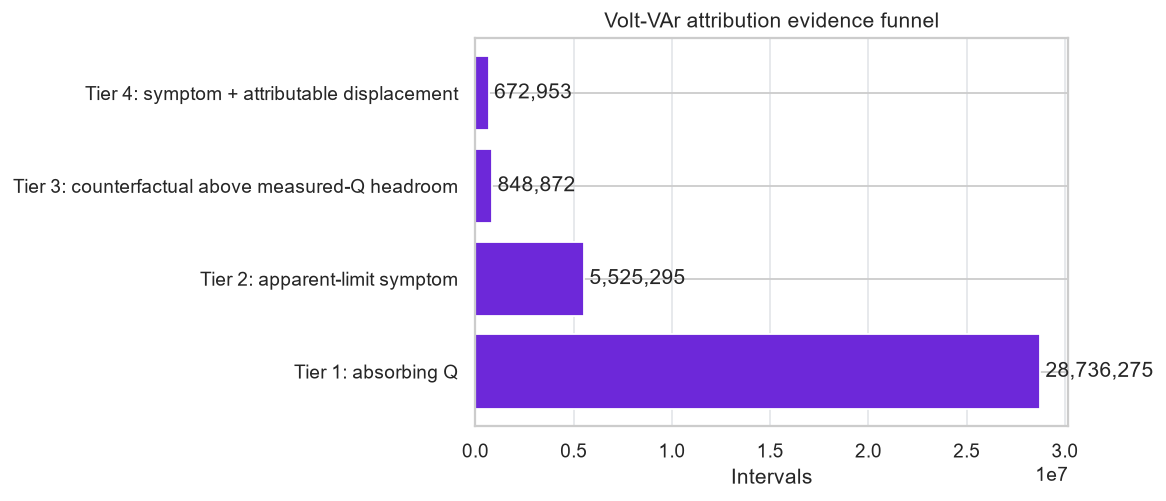

In [13]:
tiers = vm.evidence_tier_table(method_b_raw)
display(tiers)
vpl.plot_evidence_tiers(tiers);

## 4. Fleet summary, breakdowns, and concentration

This section contextualises the raw counts: what fraction of the fleet is
affected, how the attribution distributes across DNSPs, and how concentrated
the curtailment is across sites.

In [14]:
# Formatted text summary — combines Method A screening and Method B attribution
vm.print_fleet_summary(
    method_a_enriched, method_a_yearly,
    method_b_enriched, method_b_yearly,
    params,
)

VOLT-VAR CURTAILMENT — FLEET SUMMARY ([2024, 2025])

Detection window: 240–253 V,  11:00–14:00 AEST,  GHI filter ON,  flex exclude

Method A — apparent-limit symptom scan:
  Eligible sites:                              14,557
  Sites with ≥1 symptom interval:               7,253  (49.8%)
  Total eligible intervals:                62,466,408
  Total symptom intervals:                  5,525,295  (8.8452%)
  Headroom displacement proxy:               82,235.6 kWh

Method B — counterfactual attribution:
  Counterfactual-covered sites:                 14,415
  Tier 4 affected sites:                         3,790
  Tier 4 attributed intervals:                 672,953
  Attributed curtailment (measured Q):         6,369.6 kWh
  Covered potential generation:             20,596,097 kWh
  Attributed / covered potential:               0.0309%

YEAR-BY-YEAR — METHOD A
 year  eligible_sites  symptom_sites  eligible_intervals  symptom_intervals  symptom_site_pct  symptom_interval_pct  headroom_disp

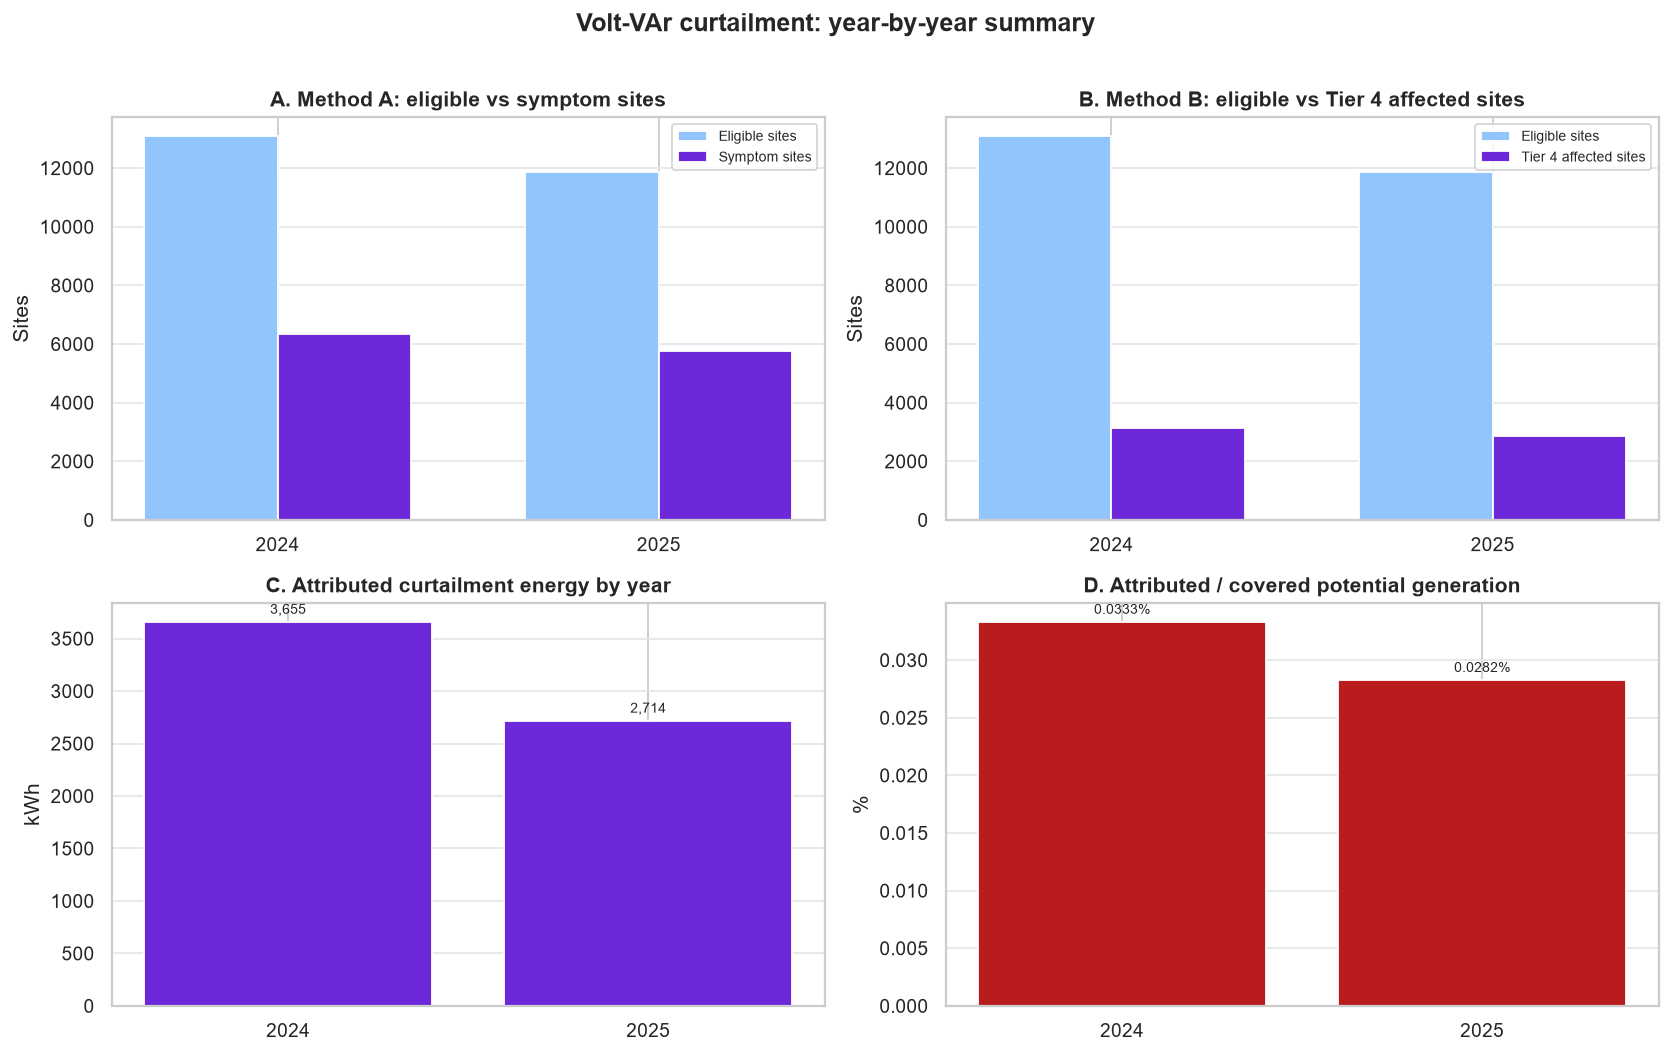

In [15]:
# Year-by-year comparison: symptom rates (Method A) vs attribution (Method B)
vpl.plot_yearly_comparison(method_a_yearly, method_b_yearly);

### 4.1 Breakdowns by DNSP

Are the affected sites concentrated in particular network areas? The
`group_breakdown` function cross-tabulates the Method B site-year results
against site metadata, keeping only groups with at least 20 sites to avoid
over-interpreting thin cells.

,dnsp_name,n_sites,affected_sites,attributed_kwh,covered_potential_kwh,affected_site_pct,attributed_pct_of_covered_potential
6,Ergon,3159,888,1566.118684,5.884991e+06,28.110161,0.026612
1,Ausgrid,2550,667,1115.399144,4.101496e+06,26.156863,0.027195
5,Energex,2296,725,834.156272,2.816824e+06,31.576655,0.029613
7,Essential,1379,413,675.934197,1.800829e+06,29.949239,0.037535
4,Endeavour,1743,357,441.745335,2.215743e+06,20.481928,0.019937
13,TasNetworks,342,132,405.982666,2.606461e+05,38.596491,0.155760
2,Ausnet,359,84,343.383781,3.174062e+05,23.398329,0.108184
11,Powercor,363,102,255.138438,3.850369e+05,28.099174,0.066263
9,Jemena,123,34,190.600867,1.503602e+05,27.642276,0.126763
12,SAPN,1170,121,148.144662,1.281119e+06,10.34188,0.011564


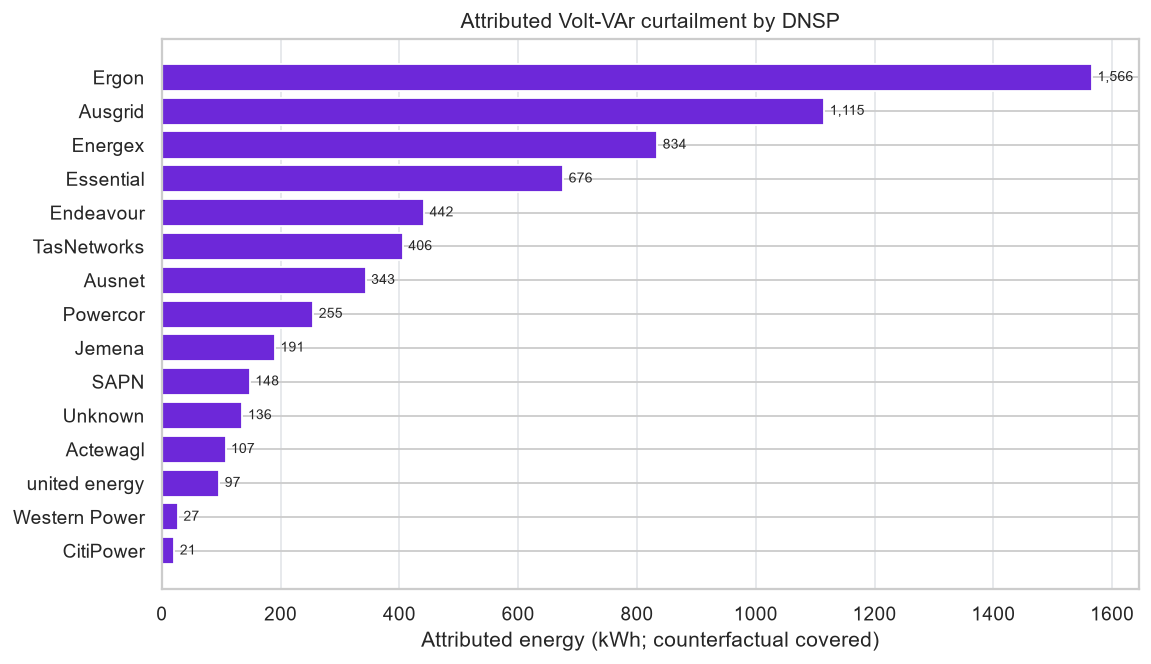

In [16]:
meta = aq(
    "SELECT DISTINCT site_id, state, dnsp_name FROM meta_up23c WHERE is_pv = True",
    database=config.database,
)
by_dnsp = vm.group_breakdown(method_b_enriched, meta, "dnsp_name")
display(by_dnsp)
vpl.plot_group_energy(by_dnsp, "dnsp_name", "Attributed Volt-VAr curtailment by DNSP");

### 4.2 Concentration / Lorenz

How concentrated is the estimated curtailment? A handful of sites usually
dominate; the Lorenz curve and the top-k shares make that explicit.

,top_site_share_pct,cumulative_energy_share_pct
0,1,13.157739
1,5,38.026048
2,10,55.841303
3,20,76.221146
4,50,96.713290


,site_id,attributed_measured_q_kwh,site_share_pct,cumulative_energy_share_pct
0,1805446999,54.075823,0.026385,0.848970
1,276149647,31.534031,0.052770,1.344042
2,2105830595,31.282103,0.079156,1.835159
3,476487840,30.942503,0.105541,2.320944
4,1484486619,28.737354,0.131926,2.772110
5,1056369556,27.398267,0.158311,3.202252
6,1598634062,27.318075,0.184697,3.631135
7,175225288,27.217590,0.211082,4.058441
8,854764866,26.882511,0.237467,4.480486
9,1859863480,25.337019,0.263852,4.878267


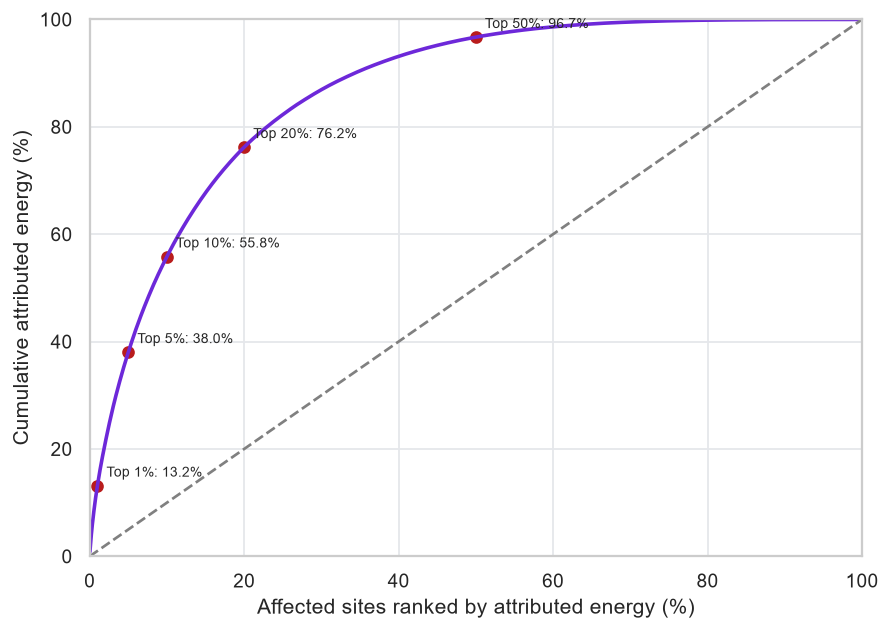

In [17]:
ranked, conc_shares = vm.concentration(method_b_enriched)

display(pd.DataFrame({
    "top_site_share_pct": conc_shares.keys(),
    "cumulative_energy_share_pct": conc_shares.values(),
}))

if not ranked.empty:
    display(ranked.head(20))
    vpl.plot_concentration(ranked, conc_shares);

## 5. Single-site: interval-level attribution

Fetch every eligible interval for one site-year and plot: voltage panel +
power traces (measured P, counterfactual P, P-headroom from measured Q, |Q|)
with symptom intervals highlighted. This is the per-interval view behind the
aggregate tier counts.

Site 276149647, 2025: 5,799 eligible intervals


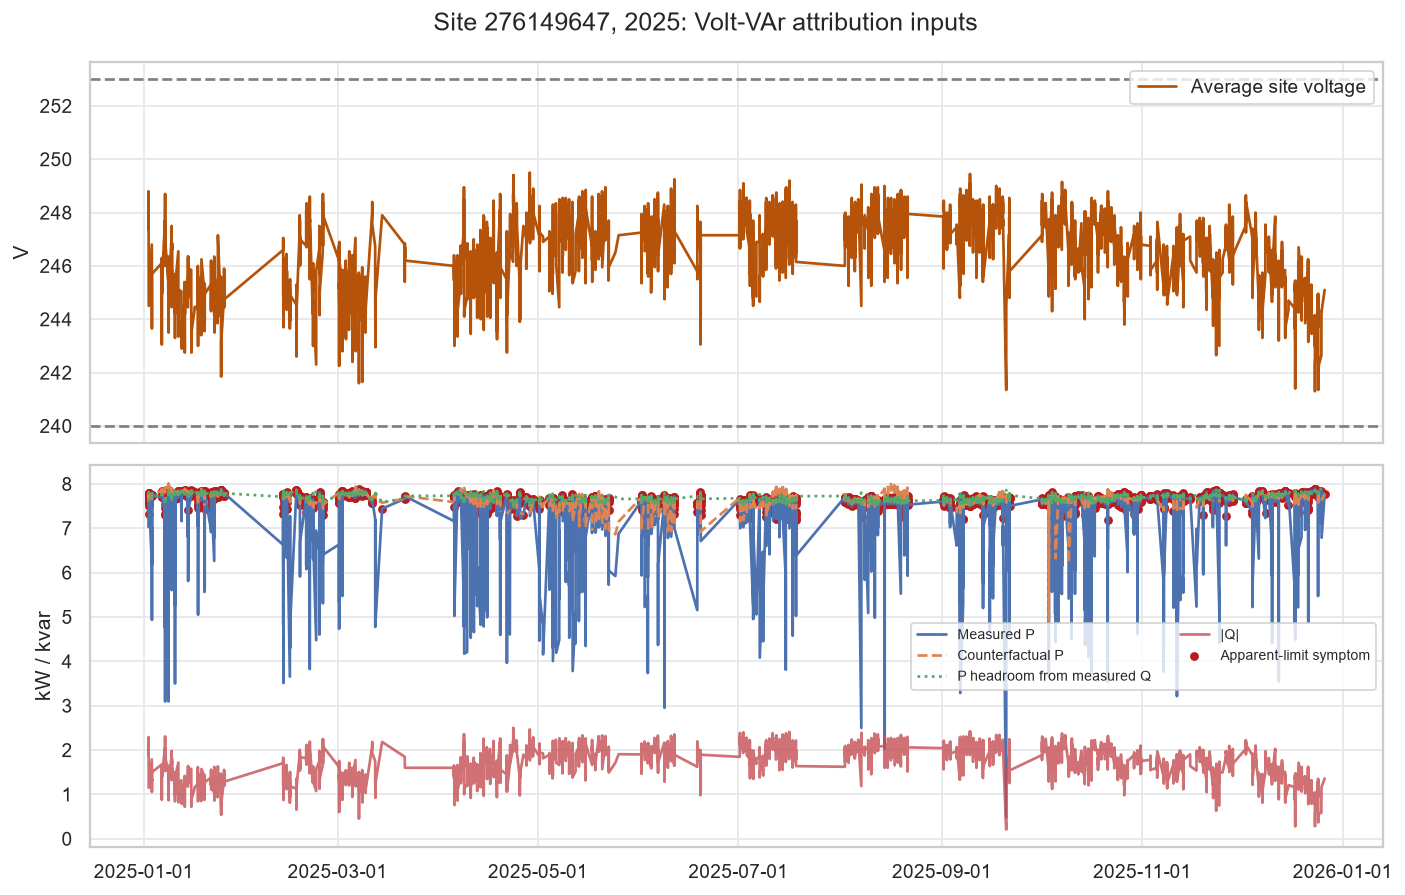

In [18]:
TARGET_SITE = 276149647
TARGET_YEAR = 2025

intervals = vq.fetch_method_b_intervals(aq, config, params,
                                         site_id=TARGET_SITE, year=TARGET_YEAR)
print(f"Site {TARGET_SITE}, {TARGET_YEAR}: {len(intervals):,} eligible intervals")
vpl.plot_site_intervals(intervals, TARGET_SITE, TARGET_YEAR);

## 6. Single-site: P–Q operating points

Each eligible interval plotted on the P–Q plane, with the empirical
apparent-power circle overlaid. Points near the circle are the intervals where
the inverter is riding its limit while absorbing VAr. Colour encodes voltage.

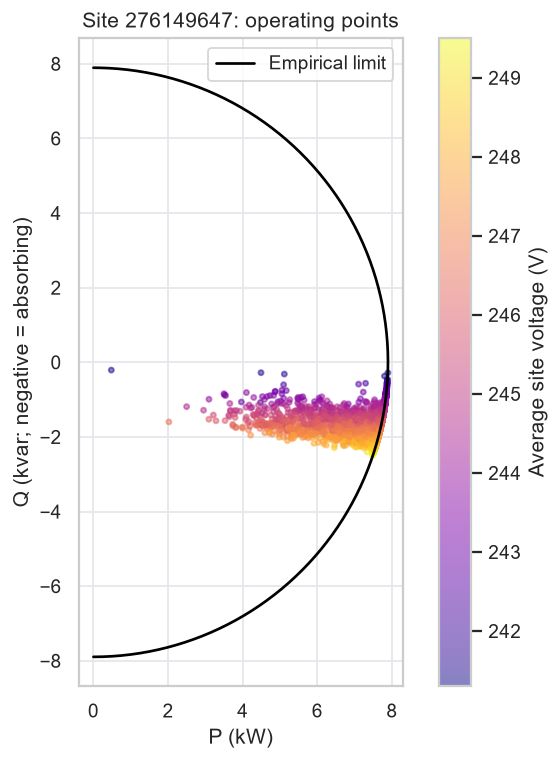

In [19]:
vpl.plot_pq_circle(intervals, TARGET_SITE);

## 7. Stage 2 baseline comparison

The Stage 2 Volt-VAr conformance table (`conformance_voltvar_v2`) already
carries per-site curtailment counts and sums computed during the pipeline
build. This is a quick sanity check: do the Stage 2 aggregates align with the
notebook's Method B totals? Discrepancies indicate filter differences
(e.g. flex-export exclusion, GHI filter, peak-hour window) that must be
understood before reporting.

In [20]:
baseline = vq.fetch_stage2_vvar_baseline(aq, config, params)
display(baseline)

,year,assessable_sites,capability_assessable_intervals,reduced_nonconf_intervals,apparent_limit_symptom_intervals,counterfactual_curtailment_intervals,curtailed_kwh
0,2024,14123,332234972,159996118,138588,6514,111.092172
1,2025,12913,291881647,134158435,90211,3761,48.022243


## 8. Notes, caveats, and next steps

**Caveats to keep in mind**

1. **`S_99` vs nameplate** — `S_99` is the empirical limit and usually the right
   choice, but for sites that have been curtailing for most of their history,
   `S_99` is itself depressed, which *under*-counts curtailment. Toggle
   `empirical_limit_basis` to compare.
2. **GHI / `all_uncurtailedpv` coverage** — Method B and the fleet-context
   denominator can't run for years outside the counterfactual table's coverage.
3. **`ghi_cs_ratio_min` and `tolerance_fraction` are tunable, not derived from
   the standard** — run a sensitivity sweep before quoting a headline number.
   Use `params.with_changes(ghi_cs_ratio_min=0.90)` and re-run.
4. **The 240–253 V band deliberately excludes the 253–258 V overlap zone** where
   V-VAr and V-Watt act together — in the overlap you can't cleanly attribute
   curtailment to VAr alone.
5. **`ghi_cs` is an empirical nearest-clear-sky-day reference, not a physical
   clear-sky model** — it inherits whatever shading/soiling/noise was present on
   that specific reference day.
6. **Peak-hour window** is currently 11:00–
   14:00 AEST. This is when P is naturally highest.

**Suggested next steps**

- Run `sensitivity_table` with different `empirical_limit_basis` / `tolerance_fraction` /
  `ghi_cs_ratio_min` values; report the range.
- Cross-tabulate affected sites by **OEM** — some inverter brands default to
  fixed-PF and won't show this symptom at all, which is itself a finding.
- Compare the Volt-VAr-curtailment site list against the Volt-Watt-curtailment
  list: sites doing *both* are losing the most generation at high voltage.

### Sensitivity example

```python
# Sweep GHI threshold
scenarios = []
for ghi_min in [0.80, 0.85, 0.90, 0.95]:
    p = params.with_changes(ghi_cs_ratio_min=ghi_min)
    raw = vq.fetch_method_b_site_year(aq, config, p)
    _, enriched = vm.method_b_summary(raw, config.interval_h)
    scenarios.append((f"GHI ≥ {ghi_min}", enriched))

display(vm.sensitivity_table(scenarios))
```